# 02 – PCA & Clustering

Apply dimensionality reduction and identify latent groups using K-Means.

# **Import Data + Libraries**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
import umap


In [ ]:
clustering_data = pd.read_csv('/content/drive/MyDrive/Capstone/cleaned_cluster_data.csv')
morbidity_outcomes = pd.read_csv('/content/drive/MyDrive/Capstone/cleaned_morbidity_outcome_data.csv')

print(f'Shape of Cluster Data:', clustering_data.shape)
display(clustering_data.head())
print(f'Shape of Morbidity Data:', morbidity_outcomes.shape)
display(morbidity_outcomes.head())

Shape of Cluster Data: (3638436, 38)


,mager,priorlive,priordead,priorterm,rf_cesarn,illb_r,m_ht_in,bmi,wtgain,combgest,...,tbo_rec,precare,mracehisp_1.0,mracehisp_2.0,mracehisp_3.0,mracehisp_4.0,mracehisp_5.0,mracehisp_6.0,mracehisp_7.0,mracehisp_Unknown
0,30,1.0,0.0,0.0,0.0,30.0,66.0,20.799999,4.0,38.0,...,2.0,3.0,0,1,0,0,0,0,0,0
1,28,0.0,0.0,0.0,0.0,36.0,67.0,20.400000,40.0,38.0,...,1.0,3.0,0,0,0,0,0,1,0,0
2,41,6.0,0.0,2.0,2.0,84.0,67.0,22.700001,28.0,37.0,...,8.0,2.0,1,0,0,0,0,0,0,0
3,29,2.0,0.0,0.0,0.0,49.0,61.0,26.400000,28.0,38.0,...,3.0,3.0,1,0,0,0,0,0,0,0
4,28,1.0,0.0,2.0,0.0,17.0,64.0,21.500000,31.0,39.0,...,4.0,2.0,1,0,0,0,0,0,0,0


Shape of Morbidity Data: (3638436, 5)


,mm_mtr,mm_plac,mm_rupt,mm_uhyst,mm_aicu
0,0,0,0,0,0
1,0,0,0,0,0
2,0,0,0,0,0
3,0,0,0,0,0
4,0,0,0,0,0


# **PCA**

## *Scale Data + Set PCA model*

In [ ]:
# Scale the Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(clustering_data)

In [ ]:
# PCA
pca = PCA(n_components = 0.90, random_state = 42)
X_pca = pca.fit_transform(X_scaled)

print('Number of PCA components:', pca.n_components_)
print('Explained Variance:', np.sum(pca.explained_variance_ratio_) * 100, '%')

Number of PCA components: 28
Explained Variance: 92.01779388589084 %


## *Determine the Best K using Inertia + Silhouette Scores*
----
sample size of 250,000

In [ ]:
# Determine Best K (Inertia + Silhouette)
sample_gen = np.random.default_rng(42)
samplesize = min(250000, len(X_pca))
sample_index = sample_gen.choice(np.arange(len(X_pca)), size = samplesize, replace = False)
X_pca_sample = X_pca[sample_index]

k_values = range(2, 11)
inertia_values = []
silhouette_values = []

for k in k_values:
  kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 'auto')
  cluster_labels = kmeans.fit_predict(X_pca_sample)
  inertia_values.append(kmeans.inertia_)
  silhouette = silhouette_score(
      X_pca_sample,
      cluster_labels,
      sample_size = 25000,
      random_state = 42
  )
  silhouette_values.append(silhouette)
  print(f'K = {k} -- Inertia = {kmeans.inertia_:.3f} -- Silhouette = {silhouette_values[-1]:.4f}')

K = 2 -- Inertia = 8007904.430 -- Silhouette = 0.2008
K = 3 -- Inertia = 7761410.208 -- Silhouette = 0.2074
K = 4 -- Inertia = 7504639.459 -- Silhouette = 0.2079
K = 5 -- Inertia = 6964149.975 -- Silhouette = 0.1889
K = 6 -- Inertia = 6627310.725 -- Silhouette = 0.1142
K = 7 -- Inertia = 6524437.617 -- Silhouette = 0.1637
K = 8 -- Inertia = 6273615.951 -- Silhouette = 0.1247
K = 9 -- Inertia = 6034647.646 -- Silhouette = 0.1386
K = 10 -- Inertia = 5813062.229 -- Silhouette = 0.1620


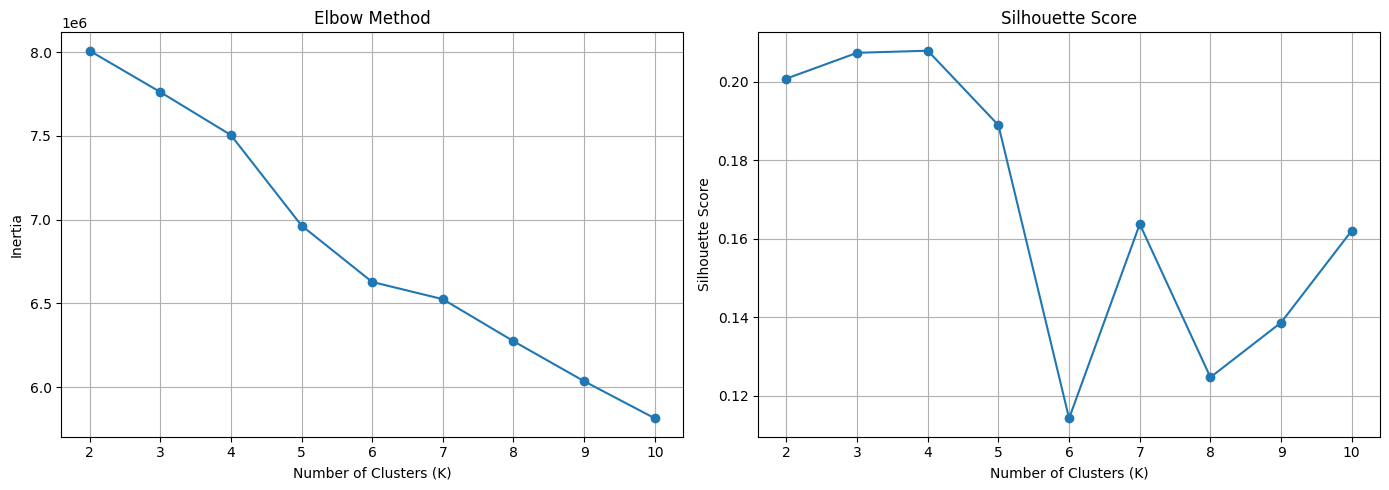

In [ ]:
# Plot Inertia + Silhouette
fig, ax = plt.subplots(1, 2, figsize = (14, 5))
ax[0].plot(list(k_values), inertia_values, marker = 'o')
ax[0].set_xlabel('Number of Clusters (K)')
ax[0].set_ylabel('Inertia')
ax[0].set_title('Elbow Method')
ax[0].grid(True)

ax[1].plot(list(k_values), silhouette_values, marker = 'o')
ax[1].set_xlabel('Number of Clusters (K)')
ax[1].set_ylabel('Silhouette Score')
ax[1].set_title('Silhouette Score')
ax[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Export K Selection Results Table
k_select_results = pd.DataFrame({
    'K': k_values,
    'Inertia': inertia_values,
    'Silhouette Score': silhouette_values
})

display(k_select_results)

# Export Results
k_select_results.to_csv('/content/drive/MyDrive/Capstone/k_select_results.csv', index = False)

,K,Inertia,Silhouette Score
0,2,8.007904e+06,0.200793
1,3,7.761410e+06,0.207361
2,4,7.504639e+06,0.207891
3,5,6.964150e+06,0.188905
4,6,6.627311e+06,0.114223
5,7,6.524438e+06,0.163706
6,8,6.273616e+06,0.124683
7,9,6.034648e+06,0.138626
8,10,5.813062e+06,0.162044


## *Run KMeans on Full Dataset*

In [ ]:
# Use Final KMean on Full Data
fulldata_kmeans = KMeans(n_clusters = 4, random_state = 42, n_init = 'auto')
fulldata_clusters = fulldata_kmeans.fit_predict(X_pca)

official_clustered_data = clustering_data.copy()
official_clustered_data['cluster'] = fulldata_clusters

cluster_count = official_clustered_data['cluster'].value_counts().sort_index()
cluster_count_percent = official_clustered_data['cluster'].value_counts(normalize = True).sort_index() * 100

print('Cluster Sizes:')
cluster_proportion = pd.concat([cluster_count, cluster_count_percent], axis = 1)
cluster_proportion.columns = ['Count', 'Percent']
display(cluster_proportion)

Cluster Sizes:


,Count,Percent
cluster,,
0,595862,16.376872
1,1193373,32.799065
2,1566805,43.062596
3,282396,7.761467


In [ ]:
# Final Silhouette Score
finalsamplesize = min(100000, len(X_pca))
finalsampleindex = sample_gen.choice(len(X_pca), size = finalsamplesize, replace=False)

final_silhouette = silhouette_score(
    X_pca[finalsampleindex],
    official_clustered_data["cluster"].iloc[finalsampleindex]
)

print(f"Final silhouette score: {final_silhouette:.4f}")

Final silhouette score: 0.0909


The final silhouette score computed on a large random sample of the clustered dataset was 0.091. Lower silhouette values are expected in large-scale biomedical datasets due to high heterogeneity among patient records. Cluster interpretation therefore relied primarily on examination of cluster profiles and clinical interpretability rather than silhouette magnitude alone.

## *Cluster Profiles*

In [ ]:
# Cluster Profiles
raw_cluster_profile = official_clustered_data.groupby('cluster').mean()
display(raw_cluster_profile.round(2))

# Export to CSV
#raw_cluster_profile.to_csv('/content/drive/MyDrive/Capstone/raw_cluster_profile.csv', index = False)

,mager,priorlive,priordead,priorterm,rf_cesarn,illb_r,m_ht_in,bmi,wtgain,combgest,...,tbo_rec,precare,mracehisp_1.0,mracehisp_2.0,mracehisp_3.0,mracehisp_4.0,mracehisp_5.0,mracehisp_6.0,mracehisp_7.0,mracehisp_Unknown
cluster,,,,,,,,,,,,,,,,,,,,,
0,33.07,3.14,0.07,1.22,0.62,52.99,63.88,31.83,26.49,37.96,...,5.23,3.21,0.44,0.22,0.01,0.03,0.01,0.03,0.24,0.01
1,27.12,0.71,0.00,0.25,0.14,45.33,63.20,30.64,28.16,38.54,...,1.97,3.20,0.01,0.25,0.01,0.02,0.00,0.05,0.64,0.02
2,30.00,0.67,0.00,0.30,0.12,38.10,64.74,27.61,32.15,38.78,...,1.97,2.75,0.88,0.01,0.00,0.10,0.00,0.01,0.00,0.00
3,31.43,1.00,0.01,0.46,0.25,48.90,63.62,32.37,25.42,38.17,...,2.47,2.93,0.44,0.10,0.01,0.13,0.00,0.02,0.29,0.01


In [ ]:
# Z-Score Cluster Profiles
z_cluster_profile = raw_cluster_profile.apply(
    lambda col: (col - col.mean()) / col.std(ddof = 0),
    axis = 0
)

display(z_cluster_profile.round(2))

# Export Z-Score Cluster Profile
#z_cluster_profile.to_csv('/content/drive/MyDrive/Capstone/z_cluster_profile.csv', index = False)

,mager,priorlive,priordead,priorterm,rf_cesarn,illb_r,m_ht_in,bmi,wtgain,combgest,...,tbo_rec,precare,mracehisp_1.0,mracehisp_2.0,mracehisp_3.0,mracehisp_4.0,mracehisp_5.0,mracehisp_6.0,mracehisp_7.0,mracehisp_Unknown
cluster,,,,,,,,,,,,,,,,,,,,,
0,1.22,1.72,1.73,1.70,1.68,1.22,0.04,0.66,-0.61,-1.27,...,1.71,0.97,-0.00,0.83,0.98,-0.82,1.10,0.28,-0.23,0.21
1,-1.50,-0.65,-0.62,-0.78,-0.72,-0.18,-1.17,0.01,0.04,0.56,...,-0.69,0.91,-1.41,1.06,0.59,-1.11,0.51,1.38,1.53,1.38
2,-0.18,-0.69,-0.67,-0.66,-0.80,-1.50,1.56,-1.63,1.60,1.31,...,-0.69,-1.41,1.42,-1.39,-1.64,0.62,-1.59,-1.40,-1.27,-1.43
3,0.47,-0.37,-0.43,-0.25,-0.16,0.47,-0.43,0.95,-1.03,-0.60,...,-0.33,-0.47,-0.00,-0.50,0.07,1.31,-0.03,-0.26,-0.03,-0.16


Calculating z-scores with
 uses the population standard deviation (dividing by
), while
 uses the sample standard deviation (dividing by
). Because the sample standard deviation is always larger, using
 results in smaller absolute z-scores, making data points appear closer to the mean than they would in a population calculation.

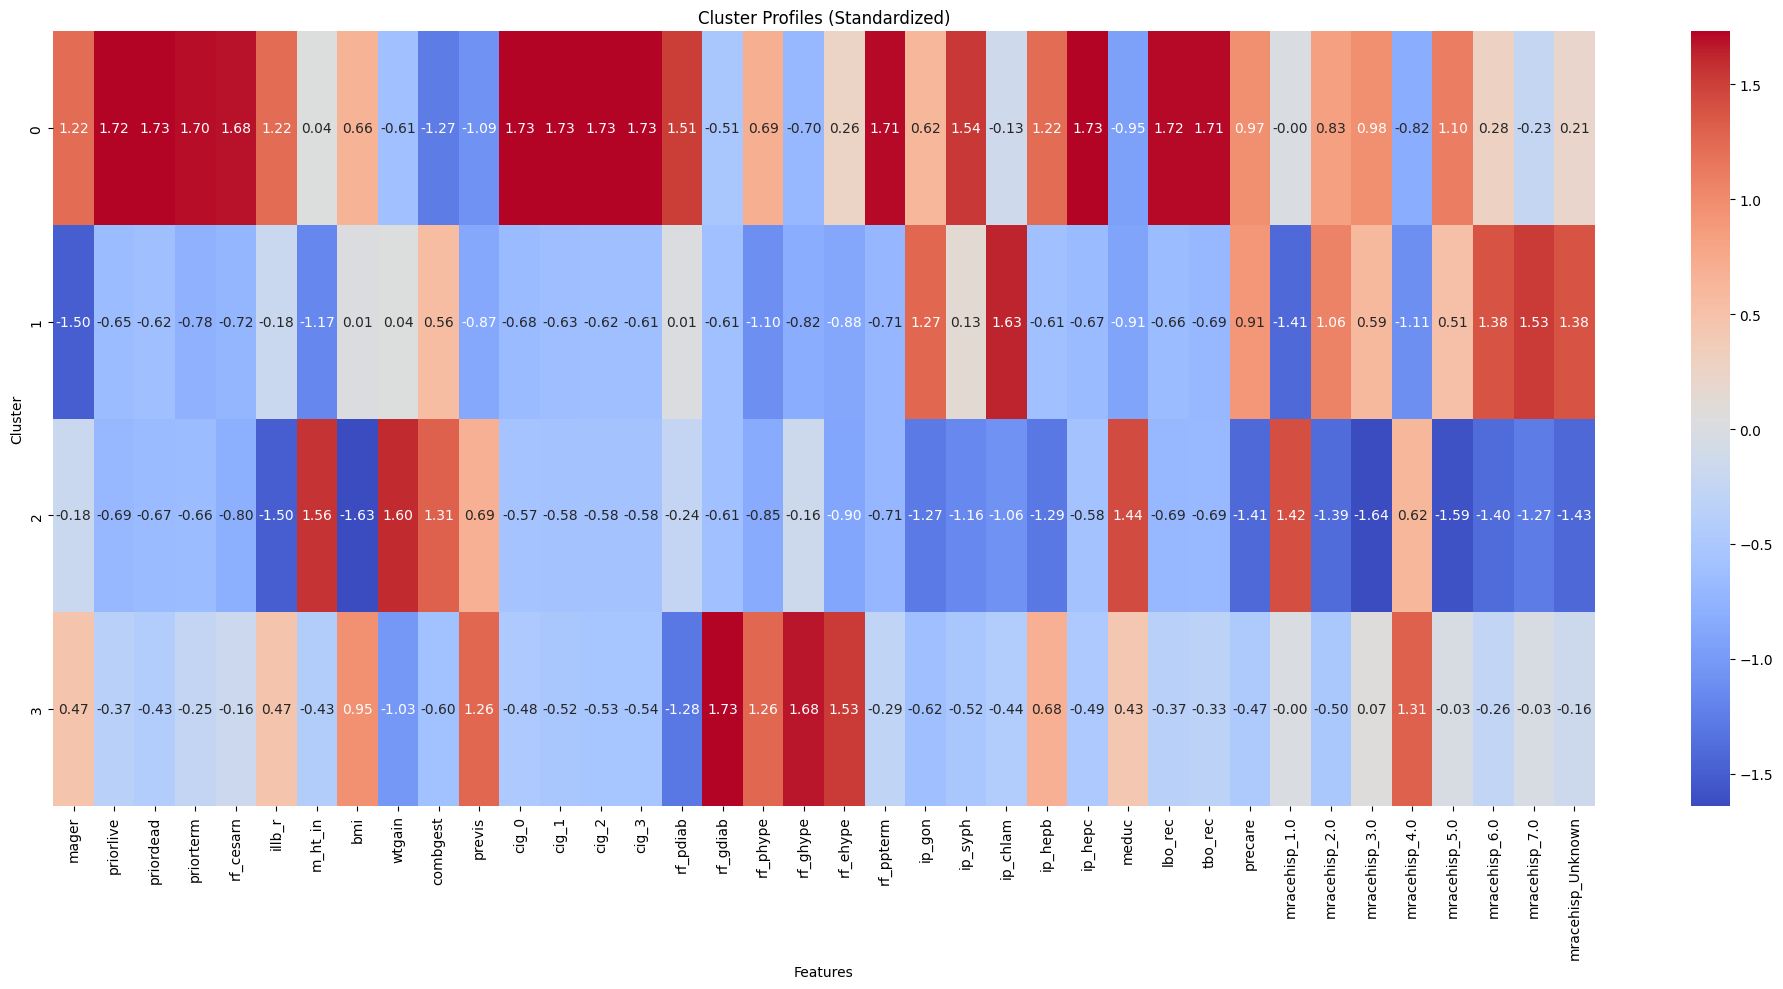

In [ ]:
# Cluster Profile Heatmap
plt.figure(figsize = (20, 10))
sns.heatmap(z_cluster_profile, annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title('Cluster Profiles (Z-Scores)')
plt.xlabel('Features')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

## *UMAP Visual Code*

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


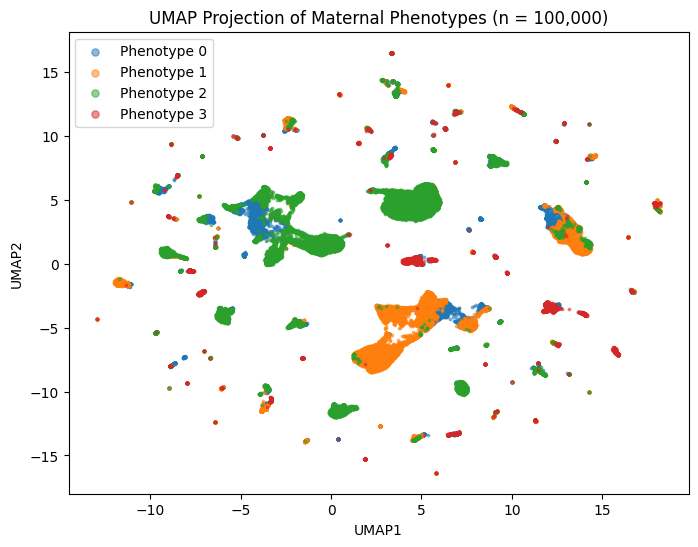

In [ ]:
# Create UMAP Sample
umap_sample_size = min(100000, len(X_pca))  # safe if dataset smaller
umap_idx = np.random.choice(len(X_pca), umap_sample_size, replace=False)
X_umap_sample = X_pca[umap_idx]
cluster_umap = official_clustered_data['cluster'].iloc[umap_idx].values
unique_clusters = np.unique(cluster_umap)
cmap = plt.cm.tab10

# UMAP
umap_model = umap.UMAP(n_neighbors = 15, min_dist = 0.0, random_state = 42)
X_umap = umap_model.fit_transform(X_umap_sample)

# UMAP Visual
plt.figure(figsize=(8,6))

for i in np.unique(cluster_umap):
    mask = cluster_umap == i
    plt.scatter(
        X_umap[mask, 0],
        X_umap[mask, 1],
        s=3,
        alpha=0.5,
        label=f'Profile {i}'
    )

plt.title(f'UMAP Projection of Maternal Risk Profiles (n = {len(X_umap):,})')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.legend(markerscale = 3)
plt.show()

## *TSNE Visual Code*

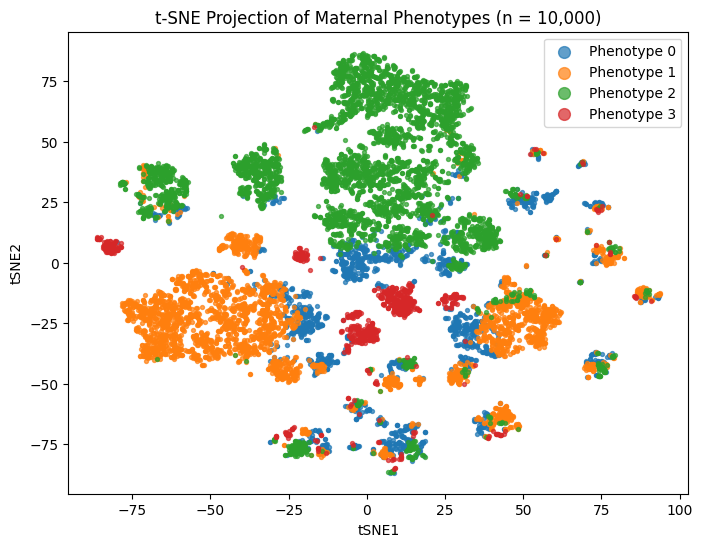

In [ ]:
# Create t-SNE sample (derived from UMAP sample)
tsne_sample_size = min(10000, len(X_umap_sample))
tsne_idx = np.random.choice(len(X_umap_sample), tsne_sample_size, replace=False)
X_tsne_sample = X_umap_sample[tsne_idx]
cluster_tsne = cluster_umap[tsne_idx]

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
X_tsne = tsne.fit_transform(X_tsne_sample)

# t-SNE Visual
plt.figure(figsize=(8,6))

for i in np.unique(cluster_tsne):
    mask = cluster_tsne == i
    plt.scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        s=8,
        alpha=0.7,
        label=f'Profiles {i}'
    )

plt.title(f't-SNE Projection of Maternal Risk Profiles (n = {len(X_tsne):,})')
plt.xlabel('tSNE1')
plt.ylabel('tSNE2')
plt.legend(markerscale = 3)
plt.show()

## *PCA Visual Code*

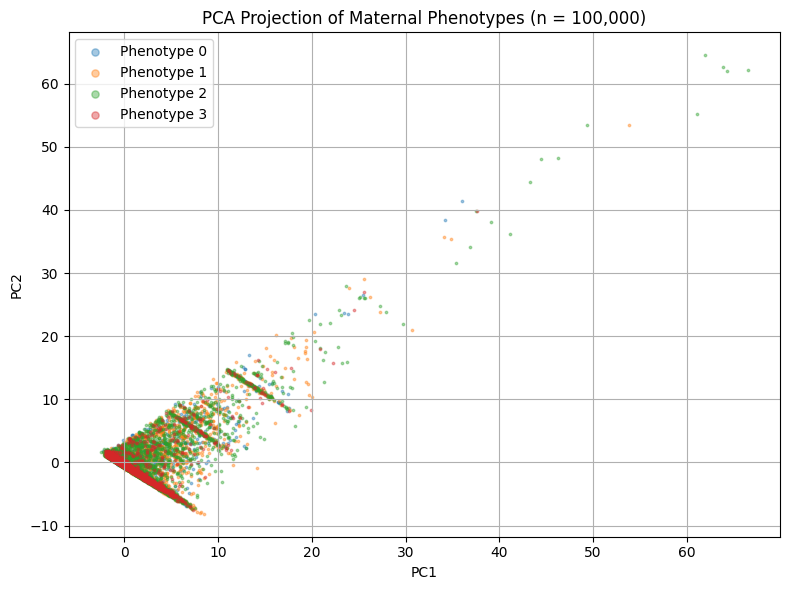

In [ ]:
# PCA
plt.figure(figsize=(8,6))

for i in np.unique(cluster_umap):
    mask = cluster_umap == i
    plt.scatter(
        X_pca_umap[mask, 0],
        X_pca_umap[mask, 1],
        s=3,
        alpha=0.4,
        label=f'Phenotype {i}'
    )

plt.title(f'PCA Projection of Maternal Phenotypes (n = {len(X_pca_umap):,})')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)

plt.legend(markerscale = 3)
plt.tight_layout()
plt.show()

## *Multi-Panel Visualization*

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


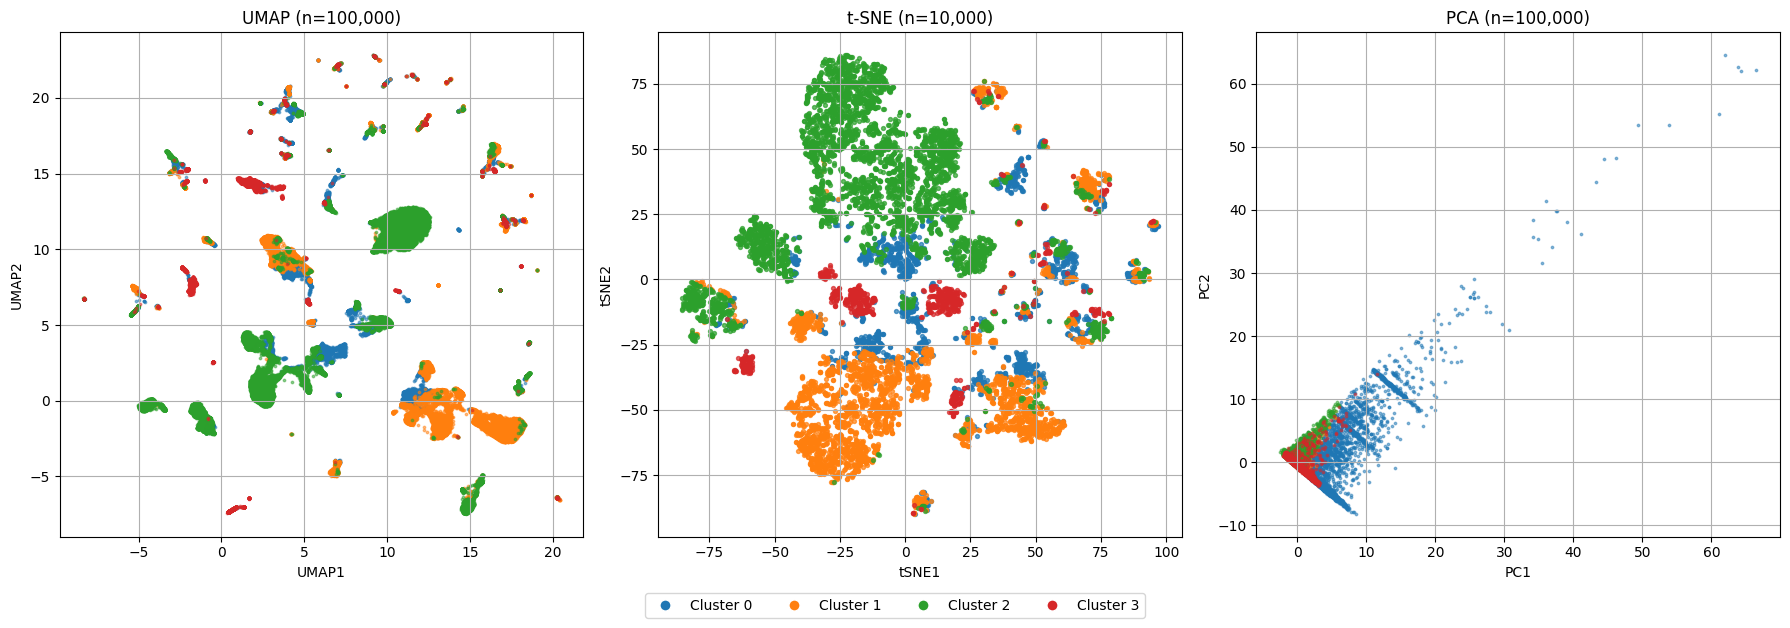

In [ ]:
# UMAP
umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.0,
    random_state=42
)

X_umap = umap_model.fit_transform(X_umap_sample)


# -----------------------------
# t-SNE SAMPLE (SUBSET OF UMAP SAMPLE)
tsne_sample_size = min(10000, len(X_umap_sample))

tsne_idx = np.random.choice(len(X_umap_sample), tsne_sample_size, replace=False)

X_tsne_sample = X_umap_sample[tsne_idx]
cluster_tsne = cluster_umap[tsne_idx]


# -----------------------------#
# t-SNE
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    random_state=42
)

X_tsne = tsne.fit_transform(X_tsne_sample)


# -----------------------------#
# PCA
X_pca_umap = X_umap_sample[:, :2]


# -----------------------------#
# 6. MULTI-PANEL PLOT
fig, ax = plt.subplots(1, 3, figsize=(18, 6))


# -------UMAP (100K)-------#
for i in unique_clusters:
    mask = cluster_umap == i
    ax[0].scatter(
        X_umap[mask, 0],
        X_umap[mask, 1],
        color=cmap(i),
        s=3,              # smaller for large sample
        alpha=0.5
    )
ax[0].set_title(f'UMAP (n = {umap_sample_size:,})')
ax[0].set_xlabel('UMAP1')
ax[0].set_ylabel('UMAP2')
ax[0].grid(True)


# -------t-SNE (10K)-------#
for i in unique_clusters:
    mask = cluster_tsne == i
    ax[1].scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        color=cmap(i),
        s=8,
        alpha=0.7
    )
ax[1].set_title(f't-SNE (n = {tsne_sample_size:,})')
ax[1].set_xlabel('tSNE1')
ax[1].set_ylabel('tSNE2')
ax[1].grid(True)


# -------PCA (100K sample)-------#
for i in unique_clusters:
    mask = cluster_umap == i
    ax[2].scatter(
        X_pca_umap[mask, 0],
        X_pca_umap[mask, 1],
        color=cmap(i),
        s=3,
        alpha=0.5
    )
ax[2].set_title(f'PCA (n = {umap_sample_size:,})')
ax[2].set_xlabel('PC1')
ax[2].set_ylabel('PC2')
ax[2].grid(True)


# -----------------------------
# 7. LEGEND
# -----------------------------
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=f'Phenotype {i}',
           markerfacecolor=cmap(i),
           markersize=8)
    for i in unique_clusters
]

fig.legend(
    handles=legend_elements,
    loc='lower center',
    ncol=len(unique_clusters),
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
plt.show()

# **Final Dataset to Export**
---
Re-introduce the outcomes

In [ ]:
final_clusters_data = pd.concat(
    [official_clustered_data, morbidity_outcomes],
    axis = 1
)
print(final_clusters_data.shape)
display(final_clusters_data.head())

# Export Final Dataset for Modeling

#final_clusters_data.to_csv('/content/drive/MyDrive/Capstone/final_clusters_data.csv', index = False)

(3638436, 72)


,mager,priorlive,priordead,priorterm,rf_cesarn,illb_r,m_ht_in,bmi,wtgain,combgest,...,PC24,PC25,PC26,PC27,PC28,mm_mtr,mm_plac,mm_rupt,mm_uhyst,mm_aicu
0,30,1.0,0.0,0.0,0.0,30.0,66.0,20.799999,4.0,38.0,...,-0.347475,-1.035728,-0.545494,-0.495967,0.706510,0,0,0,0,0
1,28,0.0,0.0,0.0,0.0,36.0,67.0,20.400000,40.0,38.0,...,0.001964,-0.500836,-0.149337,-0.197509,0.553142,0,0,0,0,0
2,41,6.0,0.0,2.0,2.0,84.0,67.0,22.700001,28.0,37.0,...,2.440121,-0.420220,-0.971641,0.191165,-0.034714,0,0,0,0,0
3,29,2.0,0.0,0.0,0.0,49.0,61.0,26.400000,28.0,38.0,...,-0.500420,-0.903385,0.658656,-0.068249,-0.818082,0,0,0,0,0
4,28,1.0,0.0,2.0,0.0,17.0,64.0,21.500000,31.0,39.0,...,3.074952,-0.645230,-1.795912,-0.101763,-0.667449,0,0,0,0,0
